# 5. Evaluation — RL vs Algorithmic Baselines

Evaluates every trained model found in `output/` against random and algorithmic routing baselines.

**What this notebook measures (all metrics are policy-agnostic):**
- Mean episode reward ± std
- Bad terminal rate (%) — lower is better
- Good terminal rate (%) — higher is better
- Mean episode length (steps)
- Relative reward improvement vs baseline(s) (%)
- Management action usage breakdown (% of steps)

**Design principles:**
- No bias toward any metric — all are shown
- Random baseline is the minimum reference point; FIFO/greedy/empirical/reward-greedy provide stronger heuristics
- No cross-system comparisons (RIMS_DRL uses resource allocation; we use routing — different problems)
- Results are reproducible: fixed seed, 500 episodes per policy


## 5.0 Setup

In [1]:
%matplotlib inline
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / 'src' / 'data_ingestion.py').exists():
        _repo_root = _p
        _src = str(_p / 'src')
        if _src not in sys.path:
            sys.path.insert(0, _src)
        break

OUTPUT_ROOT = _repo_root / 'output'
N_EVAL      = 500   # episodes per policy
SEED        = 42

plt.rcParams.update({
    'axes.facecolor': '#f8f9fa', 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#dee2e6', 'grid.linewidth': 0.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})

C = {
    'rl':     '#2196F3',   # blue
    'random': '#FF9800',   # orange
    'fifo':   '#9C27B0',   # purple
    'greedy': '#00ACC1',   # cyan
    'empirical': '#6D4C41',# brown
    'reward': '#8E24AA',   # violet
    'good':   '#4CAF50',   # green
    'bad':    '#e74c3c',   # red
    'neutral':'#9E9E9E',   # grey
}

print(f'Repo root:   {_repo_root}')
print(f'Output root: {OUTPUT_ROOT}')
print(f'Episodes per policy: {N_EVAL}')


Repo root:   /mnt/hdd/Code/Git/bwa
Output root: /mnt/hdd/Code/Git/bwa/output
Episodes per policy: 500


## 5.1 Evaluate All Models

For each dataset that has a trained model, run N_EVAL episodes under:
1. **Random policy** — uniform random routing at each step (baseline)
2. **FIFO routing** — first valid routing branch + default management action
3. **Greedy throughput** — route toward likely good terminals, avoid loops/bad terminals
4. **Empirical Markov** — imitate most likely next-step transitions from fitted log dynamics
5. **Reward-greedy (1-step)** — pick action with best immediate reward estimate
6. **RL policy** — trained MaskablePPO agent (deterministic)

Both policies use the same environment, same seed sequence, same episode count.


In [2]:
import joblib
import gymnasium as gym
from sb3_contrib import MaskablePPO
from rl_env import ProcessEnv
from kpi_actions import MANAGEMENT_ACTIONS, N_MANAGEMENT_ACTIONS
from evaluation import _select_heuristic_action

def load_env(ds_dir: Path):
    """Load ProcessEnv for a dataset directory. Returns (env, model) or None."""
    twin_path  = ds_dir / f'digital_twin_{ds_dir.name}_train.pkl'
    emb_path   = ds_dir / 'activity_embeddings.model'
    model_path = ds_dir / 'rl_model' / 'best_model.zip'
    tc_path    = ds_dir / 'terminal_classification.json'

    if not twin_path.exists() or not model_path.exists():
        return None, None

    twin     = joblib.load(twin_path)
    embedder = joblib.load(emb_path)
    tc       = json.load(open(tc_path)) if tc_path.exists() else {}
    bad_t    = set(tc.get('bad_terminals',  []))
    good_t   = set(tc.get('good_terminals', []))

    _embed_dim  = embedder.vector_size
    _median_len = twin.kpi_baselines.get('median_trace_length', 20)
    _max_steps  = max(150, int(_median_len * 4))

    env = ProcessEnv(
        twin=twin, embed_model=embedder,
        kpi_baselines=twin.kpi_baselines,
        embed_dim=_embed_dim, max_steps=_max_steps,
        bad_terminals=bad_t, good_terminals=good_t or None,
    )
    model = MaskablePPO.load(model_path, env=env)
    return env, model


def _greedy_routing_idx(env, valid_routing):
    """Pick a routing index that favours good-terminal progress and low looping."""
    successors = env._successors.get(env._current_activity, [])
    trace = env._trace
    best_idx, best_score = int(valid_routing[0]), -1e18
    for idx in valid_routing:
        idx = int(idx)
        if idx >= len(successors):
            continue
        nxt = successors[idx]
        nxt_trans = env.twin.transition_probs.get(nxt, {})
        term_prox = float(sum(p for a, p in nxt_trans.items() if a in env._all_terminals))
        score = term_prox
        if nxt in env._good_terminals: score += 1.0
        if nxt in env._bad_terminals:  score -= 2.0
        if nxt in trace[-3:]:          score -= 0.3
        if nxt not in trace:           score += 0.1
        if score > best_score:
            best_idx, best_score = idx, score
    return int(best_idx)


def _select_action(env, model, obs, mask, rng, policy_mode):
    """Select action for one of: rl, random, fifo, greedy, empirical, reward."""
    _is_md = isinstance(env.action_space, gym.spaces.MultiDiscrete)
    if _is_md:
        max_succ = int(env.action_space.nvec[0])
        route_valid = np.where(mask[:max_succ])[0]
        mgmt_valid  = np.where(mask[max_succ:])[0]
        if len(route_valid) == 0: route_valid = np.array([0])
        if len(mgmt_valid) == 0:  mgmt_valid  = np.array([0])
    else:
        route_valid = np.where(mask)[0]
        if len(route_valid) == 0: route_valid = np.array([0])
        mgmt_valid = np.array([0])

    if policy_mode == 'rl':
        action, _ = model.predict(obs, action_masks=mask, deterministic=True)
        if _is_md:
            action = np.asarray(action).reshape(-1)
            r_idx = int(action[0]) if len(action) > 0 else int(route_valid[0])
            m_idx = int(action[1]) if len(action) > 1 else 0
        else:
            return int(action)
    elif policy_mode in {'random', 'fifo', 'greedy', 'empirical', 'reward'}:
        helper_mode = {
            'random': 'random',
            'fifo': 'fifo',
            'greedy': 'greedy_throughput',
            'empirical': 'empirical_markov',
            'reward': 'reward_greedy',
        }[policy_mode]
        return _select_heuristic_action(env, mask, rng, helper_mode)
    else:
        raise ValueError(f'Unknown policy_mode: {policy_mode}')

    if _is_md:
        return np.array([r_idx, m_idx], dtype=np.int64)
    return int(r_idx)


def run_policy(env, model, n_eps, seed, policy_mode):
    """Run n_eps episodes for policy_mode in {'rl','random','fifo','greedy','empirical','reward'}."""
    rng = np.random.default_rng(seed)
    _is_md = isinstance(env.action_space, gym.spaces.MultiDiscrete)

    rewards, lengths = [], []
    good_terms = bad_terms = truncated_count = 0
    mgmt_counts = Counter()
    final_acts  = []

    for _ in range(n_eps):
        obs, _ = env.reset()
        done = trunc = False
        ep_r = steps = 0

        while not (done or trunc):
            mask = env.action_masks()
            action = _select_action(env, model, obs, mask, rng, policy_mode)
            if _is_md:
                mgmt_counts[int(action[1])] += 1

            obs, r, done, trunc, info = env.step(action)
            ep_r  += r
            steps += 1

        rewards.append(ep_r)
        lengths.append(steps)
        final_act = info.get('current_activity', '')
        final_acts.append(final_act)

        if done:
            if final_act in env._good_terminals: good_terms += 1
            elif final_act in env._bad_terminals: bad_terms  += 1
        if trunc:
            truncated_count += 1

    total_steps = sum(lengths)
    mgmt_rates  = {
        MANAGEMENT_ACTIONS[i].name: mgmt_counts[i] / max(total_steps, 1)
        for i in range(N_MANAGEMENT_ACTIONS)
    }

    return {
        'mean_reward':   float(np.mean(rewards)),
        'std_reward':    float(np.std(rewards)),
        'mean_length':   float(np.mean(lengths)),
        'good_term_pct': good_terms  / n_eps * 100,
        'bad_term_pct':  bad_terms   / n_eps * 100,
        'truncated_pct': truncated_count / n_eps * 100,
        'mgmt_rates':    mgmt_rates,
        'rewards':       rewards,
        'lengths':       lengths,
        'final_acts':    final_acts,
    }


# ── Run evaluation ─────────────────────────────────────────────────────────
all_results = {}

for ds_dir in sorted(OUTPUT_ROOT.iterdir()):
    if not ds_dir.is_dir() or ds_dir.name.startswith('.'): continue
    env, model = load_env(ds_dir)
    if env is None: continue

    ds = ds_dir.name
    print(f'Evaluating {ds}  ({len(env.twin.activities)} activities, '
          f'good={len(env._good_terminals)} bad={len(env._bad_terminals)} terminals)')

    rand_r      = run_policy(env, model, N_EVAL, SEED,     policy_mode='random')
    fifo_r      = run_policy(env, model, N_EVAL, SEED + 1, policy_mode='fifo')
    greedy_r    = run_policy(env, model, N_EVAL, SEED + 2, policy_mode='greedy')
    empirical_r = run_policy(env, model, N_EVAL, SEED + 3, policy_mode='empirical')
    reward_r    = run_policy(env, model, N_EVAL, SEED + 4, policy_mode='reward')
    rl_r        = run_policy(env, model, N_EVAL, SEED + 5, policy_mode='rl')

    rel_random = ((rl_r['mean_reward'] - rand_r['mean_reward'])
                  / max(abs(rand_r['mean_reward']), 1e-9) * 100)
    best_h = max([
        rand_r['mean_reward'], fifo_r['mean_reward'], greedy_r['mean_reward'],
        empirical_r['mean_reward'], reward_r['mean_reward']
    ])
    rel_best_heur = ((rl_r['mean_reward'] - best_h) / max(abs(best_h), 1e-9) * 100)

    all_results[ds] = {
        'random': rand_r, 'fifo': fifo_r, 'greedy': greedy_r,
        'empirical': empirical_r, 'reward': reward_r,
        'rl': rl_r,
        'rel_random': rel_random,
        'rel_best_heur': rel_best_heur,
        'n_act':  len(env.twin.activities),
        'n_good': len(env._good_terminals),
        'n_bad':  len(env._bad_terminals),
        'median_len': env._median_len,
    }
    print(f'  Random  reward={rand_r["mean_reward"]:+.2f}  '
          f'bad={rand_r["bad_term_pct"]:.1f}%  len={rand_r["mean_length"]:.1f}')
    print(f'  FIFO    reward={fifo_r["mean_reward"]:+.2f}  '
          f'bad={fifo_r["bad_term_pct"]:.1f}%  len={fifo_r["mean_length"]:.1f}')
    print(f'  Greedy  reward={greedy_r["mean_reward"]:+.2f}  '
          f'bad={greedy_r["bad_term_pct"]:.1f}%  len={greedy_r["mean_length"]:.1f}')
    print(f'  EmpMk   reward={empirical_r["mean_reward"]:+.2f}  '
          f'bad={empirical_r["bad_term_pct"]:.1f}%  len={empirical_r["mean_length"]:.1f}')
    print(f'  RwdG    reward={reward_r["mean_reward"]:+.2f}  '
          f'bad={reward_r["bad_term_pct"]:.1f}%  len={reward_r["mean_length"]:.1f}')
    print(f'  RL      reward={rl_r["mean_reward"]:+.2f}  '
          f'bad={rl_r["bad_term_pct"]:.1f}%  len={rl_r["mean_length"]:.1f}  '
          f'ΔvsRandom={rel_random:+.1f}%  ΔvsBestHeur={rel_best_heur:+.1f}%')
    print()

print(f'Done: {list(all_results.keys())}')


Evaluating BPIC2012  (24 activities, good=5 bad=4 terminals)


  Random  reward=-14.02  bad=50.0%  len=2.3
  FIFO    reward=-30.00  bad=100.0%  len=1.0
  Greedy  reward=+0.86  bad=0.0%  len=1.0
  EmpMk   reward=+1.56  bad=0.0%  len=2.0
  RwdG    reward=+0.86  bad=0.0%  len=1.0
  RL      reward=+6.59  bad=0.0%  len=10.0  ΔvsRandom=+147.0%  ΔvsBestHeur=+321.9%

Evaluating BPIC2015  (356 activities, good=5 bad=10 terminals)


  Random  reward=-3.77  bad=27.2%  len=19.7
  FIFO    reward=-147.99  bad=0.4%  len=179.3
  Greedy  reward=-0.02  bad=0.2%  len=4.0
  EmpMk   reward=-132.60  bad=0.0%  len=177.1
  RwdG    reward=+0.88  bad=0.0%  len=3.0
  RL      reward=+0.31  bad=0.0%  len=1.4  ΔvsRandom=+108.1%  ΔvsBestHeur=-65.4%

Evaluating BPIC2017  (26 activities, good=3 bad=4 terminals)


  Random  reward=-17.26  bad=61.8%  len=6.2
  FIFO    reward=+0.63  bad=0.0%  len=2.0
  Greedy  reward=+0.63  bad=0.0%  len=2.0
  EmpMk   reward=-51.56  bad=0.0%  len=150.0
  RwdG    reward=+0.63  bad=0.0%  len=2.0
  RL      reward=+2.58  bad=0.0%  len=7.0  ΔvsRandom=+114.9%  ΔvsBestHeur=+309.3%

Done: ['BPIC2012', 'BPIC2015', 'BPIC2017']


## 5.2 Summary Table

All metrics side-by-side. Lower bad terminal rate and higher good terminal rate are better.
Relative improvement is reported versus Random and versus the best heuristic baseline (max of Random/FIFO/Greedy/Empirical/Reward-greedy).


In [3]:
rows = []
for ds, res in all_results.items():
    rnd       = res['random']
    fifo      = res['fifo']
    greedy    = res['greedy']
    empirical = res['empirical']
    reward_g  = res['reward']
    rl        = res['rl']
    best_bad = min(rnd['bad_term_pct'], fifo['bad_term_pct'], greedy['bad_term_pct'], empirical['bad_term_pct'], reward_g['bad_term_pct'])
    best_good = max(rnd['good_term_pct'], fifo['good_term_pct'], greedy['good_term_pct'], empirical['good_term_pct'], reward_g['good_term_pct'])
    best_len = min(rnd['mean_length'], fifo['mean_length'], greedy['mean_length'], empirical['mean_length'], reward_g['mean_length'])
    rows.append({
        'Dataset':            ds,
        'Activities':         res['n_act'],
        'Good terminals':     res['n_good'],
        'Bad terminals':      res['n_bad'],
        'RND reward':         f"{rnd['mean_reward']:+.2f} ±{rnd['std_reward']:.2f}",
        'FIFO reward':        f"{fifo['mean_reward']:+.2f} ±{fifo['std_reward']:.2f}",
        'GRDY reward':        f"{greedy['mean_reward']:+.2f} ±{greedy['std_reward']:.2f}",
        'EMP reward':         f"{empirical['mean_reward']:+.2f} ±{empirical['std_reward']:.2f}",
        'RWDG reward':        f"{reward_g['mean_reward']:+.2f} ±{reward_g['std_reward']:.2f}",
        'RL reward':          f"{rl['mean_reward']:+.2f} ±{rl['std_reward']:.2f}",
        'RND bad %':          f"{rnd['bad_term_pct']:.1f}%",
        'FIFO bad %':         f"{fifo['bad_term_pct']:.1f}%",
        'GRDY bad %':         f"{greedy['bad_term_pct']:.1f}%",
        'EMP bad %':          f"{empirical['bad_term_pct']:.1f}%",
        'RWDG bad %':         f"{reward_g['bad_term_pct']:.1f}%",
        'RL bad %':           f"{rl['bad_term_pct']:.1f}%",
        'RND len':            f"{rnd['mean_length']:.1f}",
        'FIFO len':           f"{fifo['mean_length']:.1f}",
        'GRDY len':           f"{greedy['mean_length']:.1f}",
        'EMP len':            f"{empirical['mean_length']:.1f}",
        'RWDG len':           f"{reward_g['mean_length']:.1f}",
        'RL len':             f"{rl['mean_length']:.1f}",
        'ΔRL vs Random %':    f"{res['rel_random']:+.1f}%",
        'ΔRL vs Best Heur %': f"{res['rel_best_heur']:+.1f}%",
        'ΔRL bad vs best':    f"{rl['bad_term_pct'] - best_bad:+.1f}pp",
        'ΔRL good vs best':   f"{rl['good_term_pct'] - best_good:+.1f}pp",
        'ΔRL len vs best':    f"{rl['mean_length'] - best_len:+.1f}",
    })

df_summary = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.max_columns', 20)
display(df_summary)

df_summary.to_csv(OUTPUT_ROOT / 'evaluation_summary.csv', index=False)
print(f'Saved to {OUTPUT_ROOT / "evaluation_summary.csv"}')


,Dataset,Activities,Good terminals,Bad terminals,RND reward,FIFO reward,GRDY reward,EMP reward,RWDG reward,RL reward,...,FIFO len,GRDY len,EMP len,RWDG len,RL len,ΔRL vs Random %,ΔRL vs Best Heur %,ΔRL bad vs best,ΔRL good vs best,ΔRL len vs best
0,BPIC2012,24,5,4,-14.02 ±15.75,-30.00 ±0.00,+0.86 ±0.00,+1.56 ±0.04,+0.86 ±0.00,+6.59 ±0.15,...,1.0,1.0,2.0,1.0,10.0,+147.0%,+321.9%,+0.0pp,+0.0pp,+9.0
1,BPIC2015,356,5,10,-3.77 ±14.96,-147.99 ±7.90,-0.02 ±10.78,-132.60 ±17.01,+0.88 ±0.06,+0.31 ±0.53,...,179.3,4.0,177.1,3.0,1.4,+108.1%,-65.4%,+0.0pp,+0.0pp,-1.6
2,BPIC2017,26,3,4,-17.26 ±14.96,+0.63 ±0.00,+0.63 ±0.02,-51.56 ±0.00,+0.63 ±0.00,+2.58 ±0.11,...,2.0,2.0,150.0,2.0,7.0,+114.9%,+309.3%,+0.0pp,+0.0pp,+5.0


Saved to /mnt/hdd/Code/Git/bwa/output/evaluation_summary.csv


## 5.3 Reward Distribution — RL vs Baselines

Violin plots show the full distribution of episode rewards across all N_EVAL episodes for Random, FIFO, Greedy, and RL.
The horizontal line inside each violin is the median.


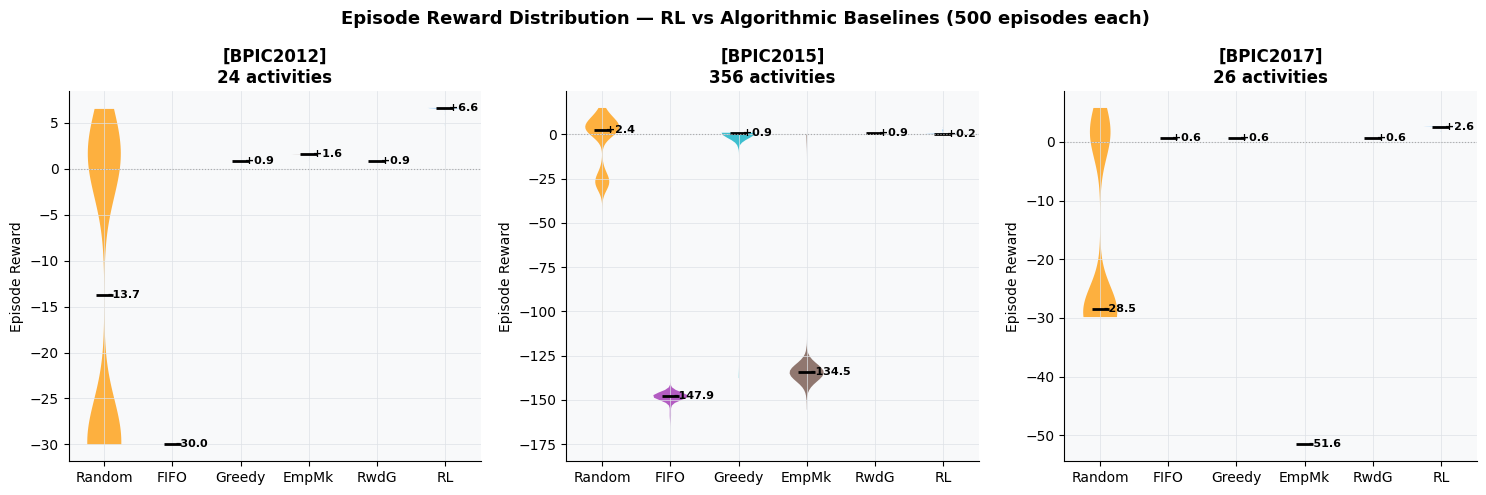

In [4]:
datasets = list(all_results.keys())
n_ds = len(datasets)

fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 5), sharey=False)
if n_ds == 1: axes = [axes]

for ax, ds in zip(axes, datasets):
    res  = all_results[ds]
    data = [
        res['random']['rewards'],
        res['fifo']['rewards'],
        res['greedy']['rewards'],
        res['empirical']['rewards'],
        res['reward']['rewards'],
        res['rl']['rewards'],
    ]
    labels = ['Random', 'FIFO', 'Greedy', 'EmpMk', 'RwdG', 'RL']
    colors = [C['random'], C['fifo'], C['greedy'], C['empirical'], C['reward'], C['rl']]

    positions = list(range(1, len(data) + 1))
    parts = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    for pc, col in zip(parts['bodies'], colors):
        pc.set_facecolor(col); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)

    ax.axhline(0, color='#aaa', lw=0.8, ls=':')
    ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Episode Reward', fontsize=10)
    ax.set_title(f'[{ds}]\n{res["n_act"]} activities', fontweight='bold')

    # Annotate medians
    for pos, d, col in zip(positions, data, colors):
        med = float(np.median(d))
        ax.text(pos, med, f' {med:+.1f}', va='center', fontsize=8,
                color='black', fontweight='bold')

fig.suptitle(f'Episode Reward Distribution — RL vs Algorithmic Baselines ({N_EVAL} episodes each)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / 'eval_reward_distribution.png', dpi=150, bbox_inches='tight')
display(fig); plt.close(fig)


## 5.4 Outcome Metrics — Bad Terminal Rate & Episode Length

**Bad terminal rate**: fraction of episodes ending at a declined/cancelled/refused activity.
Lower is better. A well-trained agent should drive this toward 0%.

**Episode length**: mean number of routing steps per episode.
Shorter is generally better (efficiency), but must not come at the cost of bad outcomes.


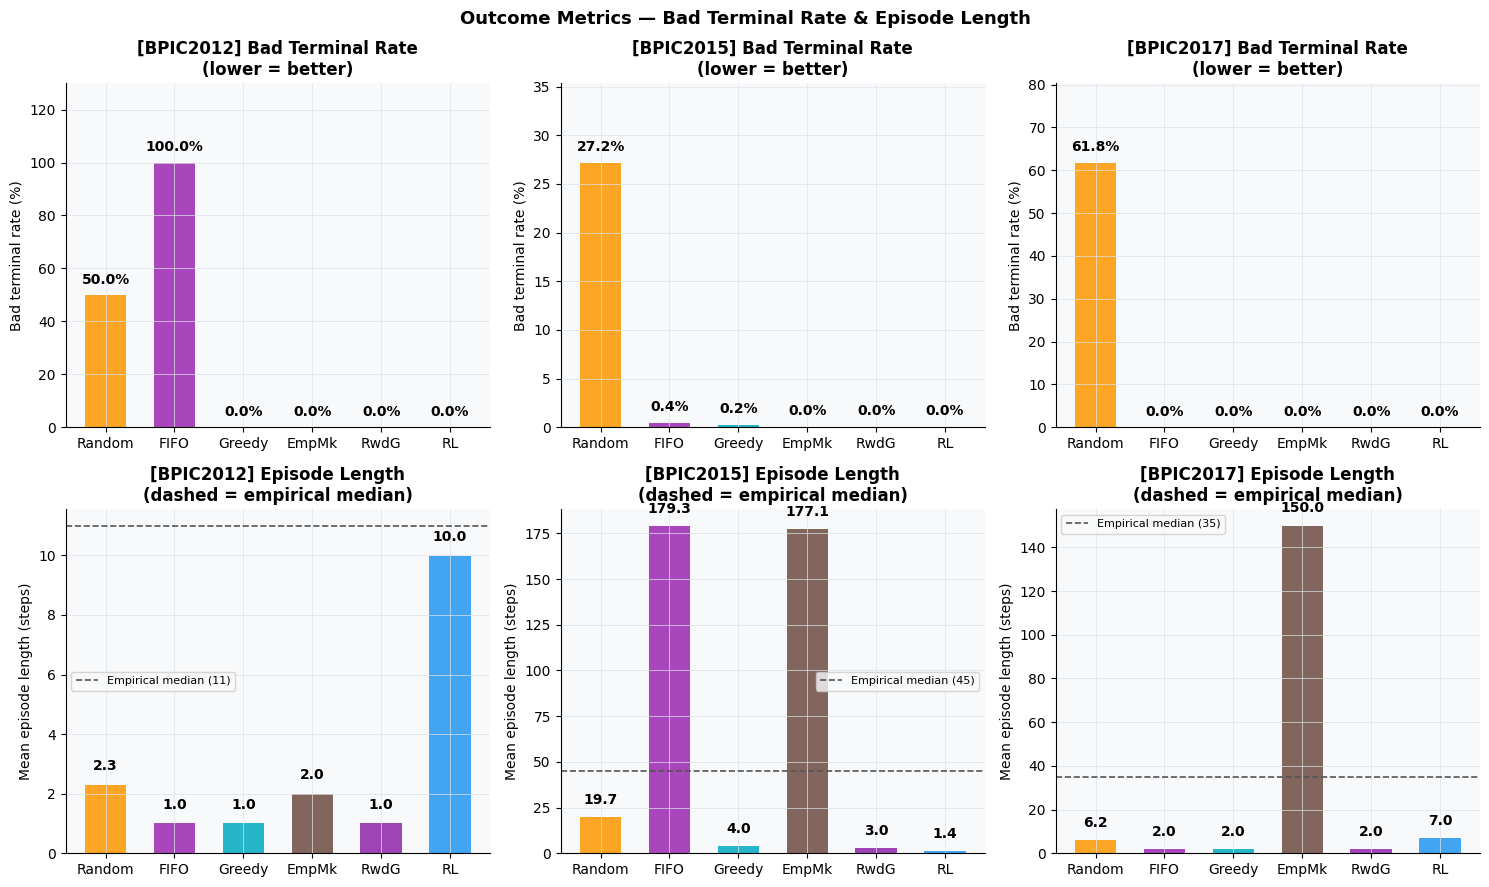

In [5]:
fig, axes = plt.subplots(2, n_ds, figsize=(5 * n_ds, 9))
if n_ds == 1: axes = axes.reshape(2, 1)

for col, ds in enumerate(datasets):
    res = all_results[ds]
    rnd       = res['random']
    fifo      = res['fifo']
    greedy    = res['greedy']
    empirical = res['empirical']
    reward_g  = res['reward']
    rl        = res['rl']

    # ── Row 0: Bad terminal rate ──────────────────────────────────────
    ax = axes[0, col]
    vals   = [rnd['bad_term_pct'], fifo['bad_term_pct'], greedy['bad_term_pct'], empirical['bad_term_pct'], reward_g['bad_term_pct'], rl['bad_term_pct']]
    labels = ['Random', 'FIFO', 'Greedy', 'EmpMk', 'RwdG', 'RL']
    xpos   = np.arange(len(labels))
    bars   = ax.bar(xpos, vals, color=[C['random'], C['fifo'], C['greedy'], C['empirical'], C['reward'], C['rl']], alpha=0.85, width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.03 + 0.1,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_ylabel('Bad terminal rate (%)')
    ax.set_title(f'[{ds}] Bad Terminal Rate\n(lower = better)', fontweight='bold')
    ax.set_ylim(0, max(max(vals) * 1.3, 5))

    # ── Row 1: Episode length ─────────────────────────────────────────
    ax = axes[1, col]
    vals2  = [rnd['mean_length'], fifo['mean_length'], greedy['mean_length'], empirical['mean_length'], reward_g['mean_length'], rl['mean_length']]
    bars2  = ax.bar(xpos, vals2, color=[C['random'], C['fifo'], C['greedy'], C['empirical'], C['reward'], C['rl']], alpha=0.85, width=0.6)
    # Reference line: empirical median trace length
    ax.axhline(res['median_len'], color='#555', lw=1.2, ls='--',
               label=f'Empirical median ({res["median_len"]:.0f})')
    for bar, v in zip(bars2, vals2):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals2) * 0.03 + 0.1,
                f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_xticks(xpos); ax.set_xticklabels(labels)
    ax.set_ylabel('Mean episode length (steps)')
    ax.set_title(f'[{ds}] Episode Length\n(dashed = empirical median)', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Outcome Metrics — Bad Terminal Rate & Episode Length',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / 'eval_outcome_metrics.png', dpi=150, bbox_inches='tight')
display(fig); plt.close(fig)


## 5.5 Relative Improvement Over Strongest Heuristic

Three metrics shown side-by-side per dataset:
- **Reward improvement** (RL vs strongest heuristic, %)
- **Bad terminal reduction** (percentage-point change vs strongest heuristic — negative = improvement)
- **Good terminal gain** (percentage-point change vs strongest heuristic — positive = improvement)

This is a stricter cross-dataset comparison: all values are relative to the strongest non-RL baseline
for that dataset, so differences in process complexity don't bias the comparison.


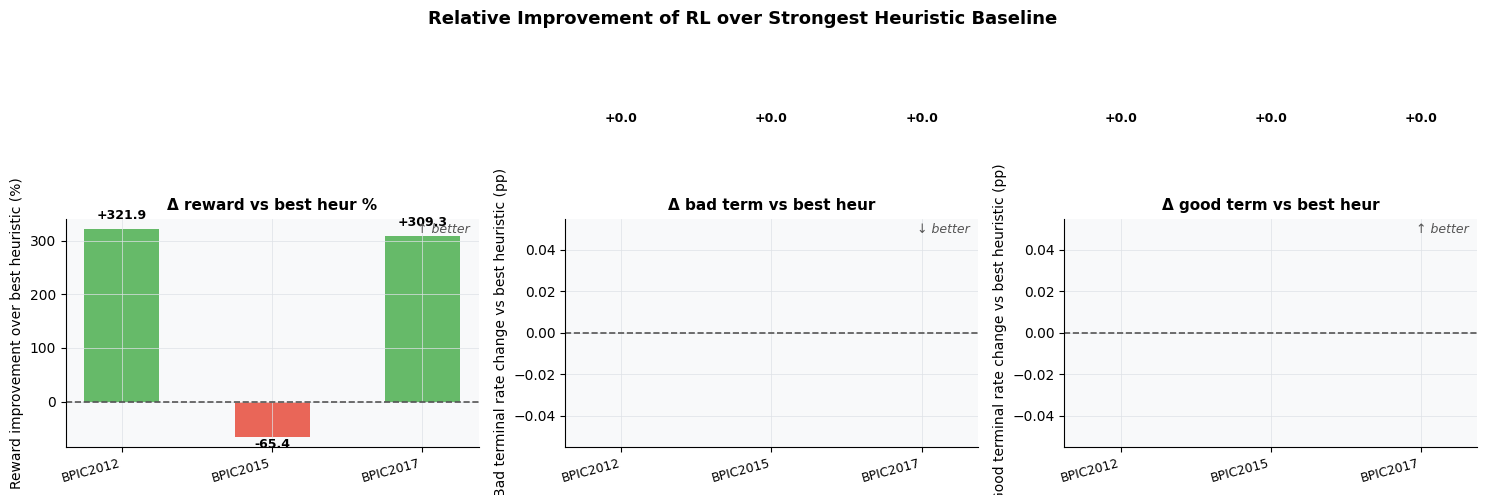

In [6]:
metrics = [
    ('Δ reward vs best heur %', 'rel_best_heur', 'Reward improvement over best heuristic (%)', C['rl'],   True),
    ('Δ bad term vs best heur', 'bad_term_pct',  'Bad terminal rate change vs best heuristic (pp)', C['bad'],  False),
    ('Δ good term vs best heur','good_term_pct', 'Good terminal rate change vs best heuristic (pp)', C['good'], True),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (title, key, ylabel, color, higher_better) in zip(axes, metrics):
    ds_labels, vals = [], []
    for ds, res in all_results.items():
        ds_labels.append(ds)
        if key == 'rel_best_heur':
            vals.append(res['rel_best_heur'])
        elif key == 'bad_term_pct':
            best_h = min(
                res['random'][key], res['fifo'][key], res['greedy'][key],
                res['empirical'][key], res['reward'][key]
            )
            vals.append(res['rl'][key] - best_h)
        else:
            best_h = max(
                res['random'][key], res['fifo'][key], res['greedy'][key],
                res['empirical'][key], res['reward'][key]
            )
            vals.append(res['rl'][key] - best_h)

    bar_colors = []
    for v in vals:
        if higher_better:
            bar_colors.append(C['good'] if v > 0 else C['bad'])
        else:
            bar_colors.append(C['good'] if v < 0 else C['bad'])

    bars = ax.bar(range(len(ds_labels)), vals, color=bar_colors, alpha=0.85, width=0.5)
    ax.axhline(0, color='#555', lw=1.2, ls='--')

    for bar, v in zip(bars, vals):
        offset = max(abs(v) for v in vals) * 0.04 + 0.1
        ypos   = v + offset if v >= 0 else v - offset * 2
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{v:+.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(ds_labels)))
    ax.set_xticklabels(ds_labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)

    note = '↑ better' if higher_better else '↓ better'
    ax.text(0.98, 0.98, note, transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#555', style='italic')

fig.suptitle('Relative Improvement of RL over Strongest Heuristic Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / 'eval_relative_improvement.png', dpi=150, bbox_inches='tight')
display(fig); plt.close(fig)


## 5.6 Management Action Usage

Which KPI-based interventions does the RL agent use, and how does that compare to the strongest heuristic baseline?

Actions the RL uses **more** than random indicate learned KPI-driven behaviour.
Actions the RL uses **less** than random indicate deliberate avoidance.
Only actions with >0.5% usage in either policy are shown.


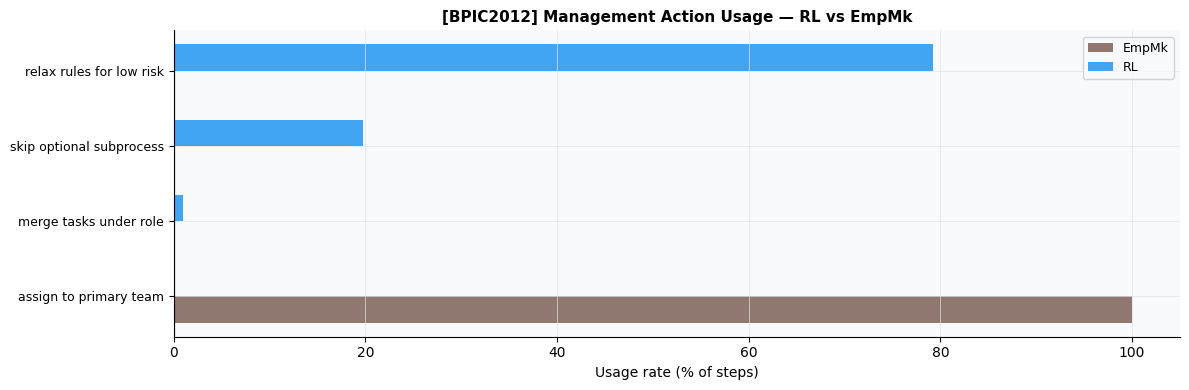

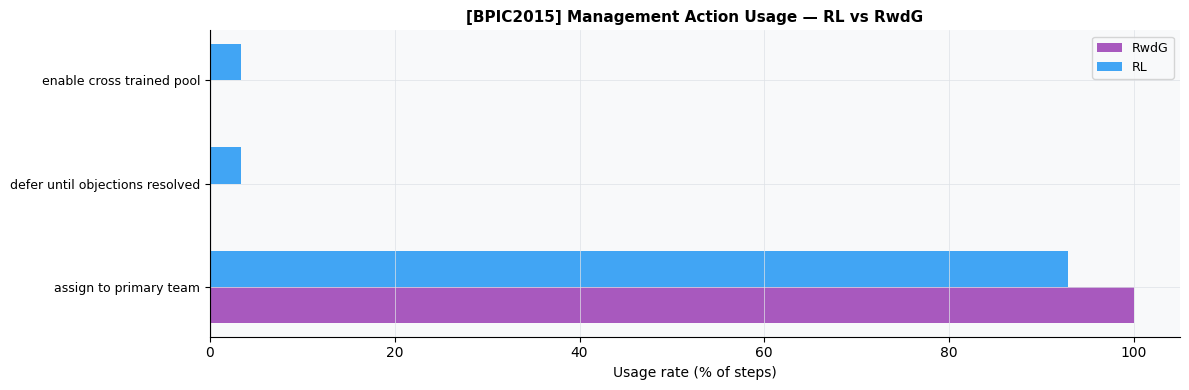

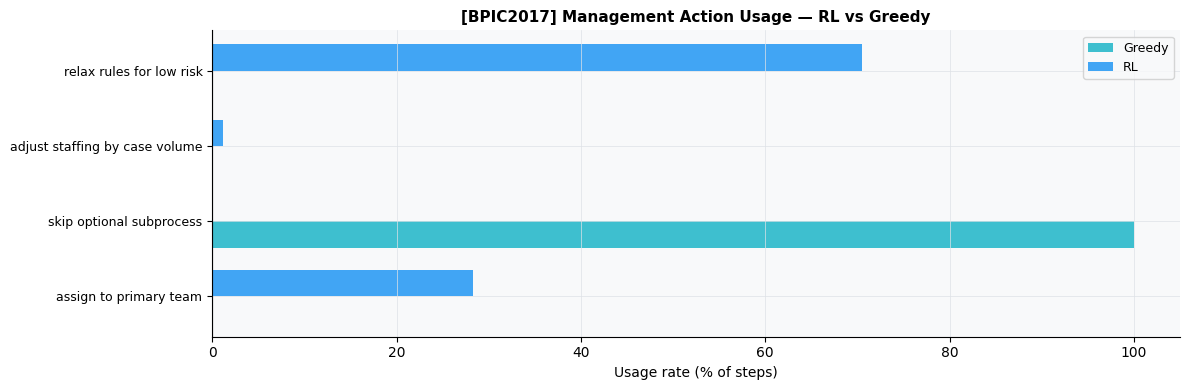

In [7]:
for ds, res in all_results.items():
    rl_rates = res['rl']['mgmt_rates']
    heuristics = {
        'Random': res['random'],
        'FIFO': res['fifo'],
        'Greedy': res['greedy'],
        'EmpMk': res['empirical'],
        'RwdG': res['reward'],
    }
    base_name, base_data = max(heuristics.items(), key=lambda kv: kv[1]['mean_reward'])
    base_rates = base_data['mgmt_rates']

    # Filter to actions used >0.5% by either policy
    visible = [a for a in MANAGEMENT_ACTIONS
               if rl_rates.get(a.name, 0) > 0.005 or base_rates.get(a.name, 0) > 0.005]
    if not visible: continue

    fig, ax = plt.subplots(figsize=(12, max(4, len(visible) * 0.55)))
    y_pos = np.arange(len(visible))
    bw    = 0.35

    rl_vals   = [rl_rates.get(a.name,   0) * 100 for a in visible]
    base_vals = [base_rates.get(a.name, 0) * 100 for a in visible]

    base_color = {
        'Random': C['random'], 'FIFO': C['fifo'], 'Greedy': C['greedy'],
        'EmpMk': C['empirical'], 'RwdG': C['reward']
    }.get(base_name, C['neutral'])
    ax.barh(y_pos - bw/2, base_vals, bw, label=base_name, color=base_color, alpha=0.75)
    ax.barh(y_pos + bw/2, rl_vals,  bw, label='RL',     color=C['rl'],     alpha=0.85)

    ax.set_yticks(y_pos)
    ax.set_yticklabels([a.name.replace('_', ' ') for a in visible], fontsize=9)
    ax.set_xlabel('Usage rate (% of steps)', fontsize=10)
    ax.set_title(f'[{ds}] Management Action Usage — RL vs {base_name}',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.axvline(0, color='#555', lw=0.8)

    plt.tight_layout()
    fig.savefig(OUTPUT_ROOT / f'eval_mgmt_actions_{ds}.png', dpi=150, bbox_inches='tight')
    display(fig); plt.close(fig)


## 5.7 Terminal Outcome Breakdown

Where do episodes end? Stacked bar showing good terminal, bad terminal, and truncated
(hit max_steps without reaching any terminal) for both policies.


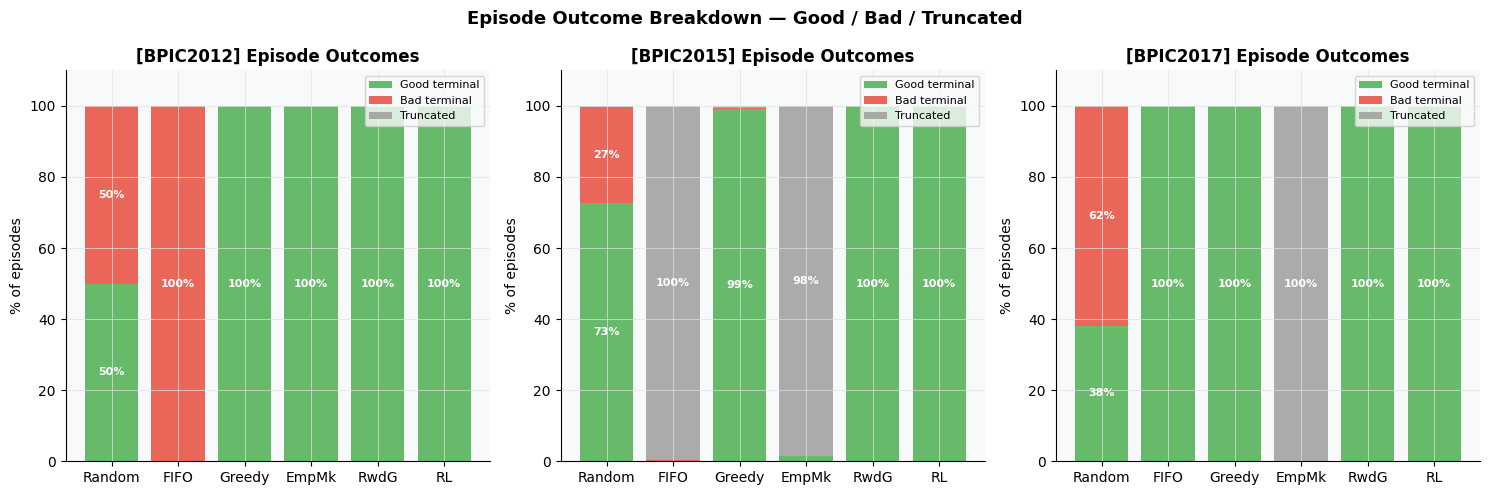

In [8]:
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 5))
if n_ds == 1: axes = [axes]

for ax, ds in zip(axes, datasets):
    res = all_results[ds]
    policies = ['Random', 'FIFO', 'Greedy', 'EmpMk', 'RwdG', 'RL']
    data     = [res['random'], res['fifo'], res['greedy'], res['empirical'], res['reward'], res['rl']]

    good_vals  = [d['good_term_pct']  for d in data]
    bad_vals   = [d['bad_term_pct']   for d in data]
    trunc_vals = [d['truncated_pct']  for d in data]

    x = np.arange(len(policies))
    ax.bar(x, good_vals,  label='Good terminal', color=C['good'],    alpha=0.85)
    ax.bar(x, bad_vals,   label='Bad terminal',  color=C['bad'],     alpha=0.85,
           bottom=good_vals)
    ax.bar(x, trunc_vals, label='Truncated',     color=C['neutral'], alpha=0.85,
           bottom=[g + b for g, b in zip(good_vals, bad_vals)])

    ax.set_xticks(x); ax.set_xticklabels(policies)
    ax.set_ylabel('% of episodes')
    ax.set_ylim(0, 110)
    ax.set_title(f'[{ds}] Episode Outcomes', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')

    for xi, (g, b, t) in enumerate(zip(good_vals, bad_vals, trunc_vals)):
        if g > 3:  ax.text(xi, g/2,       f'{g:.0f}%',  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        if b > 3:  ax.text(xi, g + b/2,   f'{b:.0f}%',  ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        if t > 3:  ax.text(xi, g + b + t/2,f'{t:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

fig.suptitle('Episode Outcome Breakdown — Good / Bad / Truncated',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_ROOT / 'eval_outcome_breakdown.png', dpi=150, bbox_inches='tight')
display(fig); plt.close(fig)


## 5.8 Save Full Results

In [9]:
rows = []
for ds, res in all_results.items():
    for policy_name, data in [
        ('Random', res['random']),
        ('FIFO', res['fifo']),
        ('Greedy', res['greedy']),
        ('Empirical Markov', res['empirical']),
        ('Reward Greedy', res['reward']),
        ('RL', res['rl']),
    ]:
        mgmt = data['mgmt_rates']
        top_mgmt = max(mgmt, key=mgmt.get) if mgmt else 'N/A'
        rows.append({
            'dataset':       ds,
            'policy':        policy_name,
            'n_activities':  res['n_act'],
            'n_good_terms':  res['n_good'],
            'n_bad_terms':   res['n_bad'],
            'mean_reward':   round(data['mean_reward'],  3),
            'std_reward':    round(data['std_reward'],   3),
            'mean_length':   round(data['mean_length'],  2),
            'good_term_pct': round(data['good_term_pct'],1),
            'bad_term_pct':  round(data['bad_term_pct'], 1),
            'truncated_pct': round(data['truncated_pct'],1),
            'top_mgmt_action': top_mgmt,
            'top_mgmt_rate': round(mgmt.get(top_mgmt, 0) * 100, 1),
            'rel_reward_vs_random_pct': round(res['rel_random'], 2) if policy_name == 'RL' else None,
            'rel_reward_vs_best_heur_pct': round(res['rel_best_heur'], 2) if policy_name == 'RL' else None,
        })

df_full = pd.DataFrame(rows)
out_path = OUTPUT_ROOT / 'evaluation_full.csv'
df_full.to_csv(out_path, index=False)
print(f'Saved to {out_path}')
display(df_full)


Saved to /mnt/hdd/Code/Git/bwa/output/evaluation_full.csv


,dataset,policy,n_activities,n_good_terms,n_bad_terms,mean_reward,std_reward,mean_length,good_term_pct,bad_term_pct,truncated_pct,top_mgmt_action,top_mgmt_rate,rel_reward_vs_random_pct,rel_reward_vs_best_heur_pct
0,BPIC2012,Random,24,5,4,-14.024,15.751,2.30,50.0,50.0,0.0,relax_rules_for_...,33.6,NaN,NaN
1,BPIC2012,FIFO,24,5,4,-30.000,0.000,1.00,0.0,100.0,0.0,assign_to_primar...,100.0,NaN,NaN
2,BPIC2012,Greedy,24,5,4,0.859,0.000,1.00,100.0,0.0,0.0,skip_optional_su...,100.0,NaN,NaN
3,BPIC2012,Empirical Markov,24,5,4,1.561,0.044,2.00,100.0,0.0,0.0,assign_to_primar...,100.0,NaN,NaN
4,BPIC2012,Reward Greedy,24,5,4,0.859,0.000,1.00,100.0,0.0,0.0,assign_to_primar...,100.0,NaN,NaN
5,BPIC2012,RL,24,5,4,6.585,0.147,9.98,100.0,0.0,0.0,relax_rules_for_...,79.2,146.96,321.90
6,BPIC2015,Random,356,5,10,-3.765,14.963,19.75,72.6,27.2,0.2,assign_to_primar...,26.9,NaN,NaN
7,BPIC2015,FIFO,356,5,10,-147.987,7.897,179.28,0.0,0.4,99.6,assign_to_primar...,100.0,NaN,NaN
8,BPIC2015,Greedy,356,5,10,-0.024,10.782,3.99,99.2,0.2,0.6,skip_optional_su...,75.2,NaN,NaN
9,BPIC2015,Empirical Markov,356,5,10,-132.599,17.010,177.14,1.6,0.0,98.4,assign_to_primar...,100.0,NaN,NaN
